# Decision Tree Regression
##### Owen Lindsey
##### Professor Majumdar
##### AIT-110: Statistical Learning Theory
##### Grand Canyon University
##### Date: 02/28/2026
##### Video Link: https://www.youtube.com/watch?v=FfBT1elOQ1M

# Understanding Decision Trees and Random Forests

## 1. Building a Decision Tree

***Tree Structure*** -- Decision Trees are comprised of a ***root node***, ***intermediate nodes***, and ***leaf nodes***. These trees may look abnormal, due to the root being the top most node, with the rest of the nodes following BELOW and splitting based on deterministic outcomes.

***Choosing Splits*** -- The algorithm works by evaluating all possible splits across all features to find the best one. For each feature, it tests different threshold values and calculates the resulting purity of the child nodes. The split that produces the greatest improvement in purity (or reduction in impurity) is chosen.

***Measuring Purity*** -- For classification, the Gini Index measures impurity, where values closer to 0 indicate purer nodes (0 is completely pure). Information Gain measures how much information was gained by splitting at a specific location. For regression trees, we use variance reduction or MSE (Mean Squared Error) to measure split quality - choosing splits that minimize the variance within each child node.

***Pruning*** -- To prevent overfitting, trees can be pruned using two approaches:
- **Pre-pruning**: Stop growing the tree early by setting constraints (max depth, minimum samples per leaf, minimum impurity decrease)
- **Post-pruning**: Grow a full tree, then remove branches that don't improve performance on validation data using cost-complexity pruning (alpha parameter)

## 2. Limitations of Decision Trees

Decision trees have several key limitations:
- **High Variance**: Small changes in data can result in completely different tree structures, making them unstable
- **Overfitting**: Trees can grow too complex and memorize training data rather than learning generalizable patterns
- **Greedy Algorithm**: Trees make locally optimal decisions at each split, which may not lead to the globally optimal tree
- **Difficulty with Linear Relationships**: Trees struggle to model simple linear relationships efficiently

***How Random Forests Address These*** -- Random Forests tackle these limitations by combining multiple trees trained on different subsets of data with random feature selection. This ensemble approach reduces variance and overfitting while maintaining predictive power.

## 3. Random Forest Algorithm

***Combining Multiple Trees*** -- Random Forests improve model performance by creating an ensemble of decision trees and aggregating their predictions. For regression, predictions are averaged; for classification, the majority vote is used.

***Bootstrapping (Bagging)*** -- Each tree is trained on a bootstrapped sample of the original dataset. This means randomly sampling the data with replacement, so each tree sees a slightly different version of the data (typically ~63% unique samples, with some repeated).

***Random Feature Selection*** -- At each split in each tree, only a random subset of features is considered (typically √p for classification or p/3 for regression, where p is the total number of features). This decorrelates the trees, preventing them from all making the same mistakes.

## 4. Variance Reduction

***How It Works*** -- By averaging predictions across many trees, Random Forests significantly reduce variance compared to a single decision tree. Each individual tree may overfit to its particular bootstrap sample, but these overfitting patterns are different across trees. When averaged, the overfitting cancels out while the true signal remains.

***Benefits for Accuracy*** -- Lower variance means the model generalizes better to unseen data. While individual trees have low bias but high variance, Random Forests maintain that low bias while achieving much lower variance. This leads to more stable predictions and better performance on test data.

## 5. Variable Importance

***Measuring Importance*** -- Random Forests provide two main metrics for variable importance:

1. **Mean Decrease in Impurity (MDI)**: Measures how much each feature decreases the weighted impurity (Gini or MSE) across all trees. Features that create larger decreases in impurity are more important.

2. **Permutation Importance**: Measures how much the model's accuracy decreases when a feature's values are randomly shuffled. Features that cause larger drops in accuracy when permuted are more important.

***Interpretation and Use*** -- Variable importance scores help identify which features contribute most to predictions. This is useful for:
- Feature selection (removing unimportant features)
- Understanding the underlying relationships in the data
- Communicating model insights to stakeholders
- Debugging model behavior 



# 2. Building Decision Trees and Random Forests



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38444 entries, 0 to 38443
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         38444 non-null  int64  
 1   Age                38444 non-null  int64  
 2   Gender             38444 non-null  object 
 3   Country            38444 non-null  object 
 4   Income             38444 non-null  int64  
 5   ProductQuality     38444 non-null  int64  
 6   ServiceQuality     38444 non-null  int64  
 7   PurchaseFrequency  38444 non-null  int64  
 8   FeedbackScore      38444 non-null  object 
 9   LoyaltyLevel       38444 non-null  object 
 10  SatisfactionScore  38444 non-null  float64
dtypes: float64(1), int64(6), object(4)
memory usage: 3.2+ MB


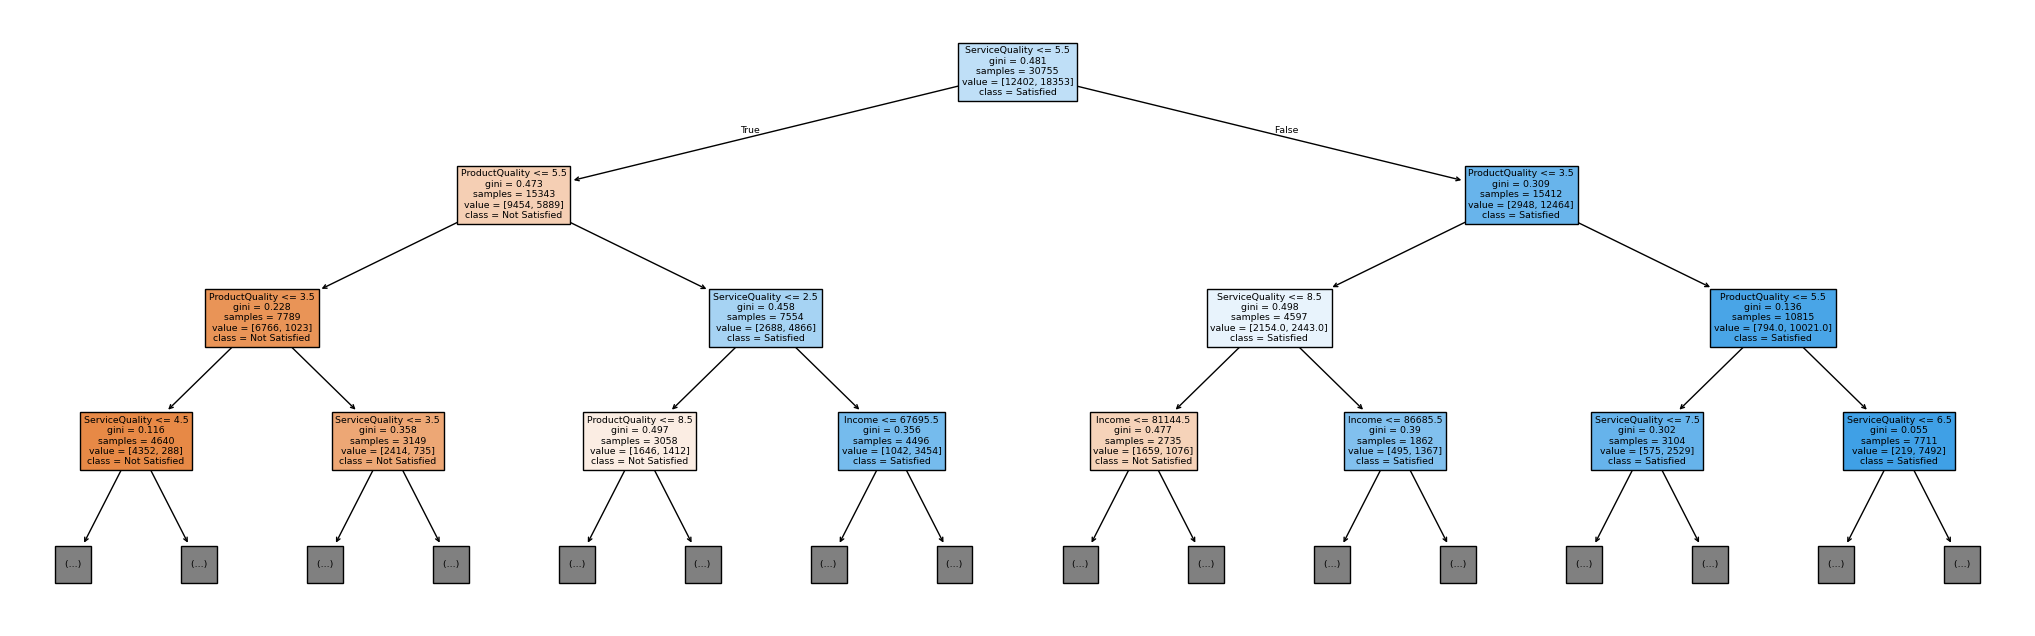

In [35]:
import warnings
warnings.filterwarnings('ignore')
from math import comb
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, accuracy_score
from sklearn.datasets import *
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split





from IPython.display import Image, display_svg, SVG
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import pandas as pd
import numpy as np
%matplotlib inline

customer_data = pd.read_csv('data/customer_feedback_satisfaction.csv')

customer_data.head()

customer_data.info()

feedback_map = {'Low': 0, 'Medium': 1, 'High': 2}
loyalty_map = {'Bronze': 0, 'Silver': 1, 'Gold': 2}

customer_data['FeedbackScore'] = customer_data['FeedbackScore'].map(feedback_map)
customer_data['LoyaltyLevel'] = customer_data['LoyaltyLevel'].map(loyalty_map)
customer_data['Gender'] = customer_data['Gender'].map({'Male': 0, 'Female': 1})
customer_data['Country'] = customer_data['Country'].map({'United States': 0, 'Canada': 1, 'Mexico': 2, 'Other': 3})
# Define Satisfaction Score as a binary variable Yes if >= 85 and No if < 85
customer_data['Satisfied'] = (customer_data['SatisfactionScore'] >= 85).astype(int)


X_train, X_test, y_train, y_test = train_test_split(
    customer_data[['Age','Gender','Country','Income','ProductQuality','ServiceQuality','PurchaseFrequency','FeedbackScore','LoyaltyLevel']],
    customer_data['Satisfied'],
    test_size=0.2,
    random_state=42
)

dt_classifier = DecisionTreeClassifier()

dt_classifier.fit(X_train, y_train)

plt.figure(figsize=(26,8))
plot_tree(dt_classifier, filled=True, feature_names=X_train.columns, class_names=['Not Satisfied', 'Satisfied'], max_depth=3)
plt.show()


       alpha  impurity  leaves  cost function
0   0.000000  0.000000    4227  0.000 + 4227α
1   0.000019  0.001623    4128  0.002 + 4128α
2   0.000021  0.002834    4062  0.003 + 4062α
3   0.000021  0.004077    4002  0.004 + 4002α
4   0.000021  0.005406    3945  0.005 + 3945α
..       ...       ...     ...            ...
86  0.000184  0.190416     105   0.190 + 105α
87  0.000233  0.195925      79    0.196 + 79α
88  0.000338  0.201904      58    0.202 + 58α
89  0.000616  0.211977      36    0.212 + 36α
90  0.002549  0.235707      16    0.236 + 16α

[91 rows x 4 columns]


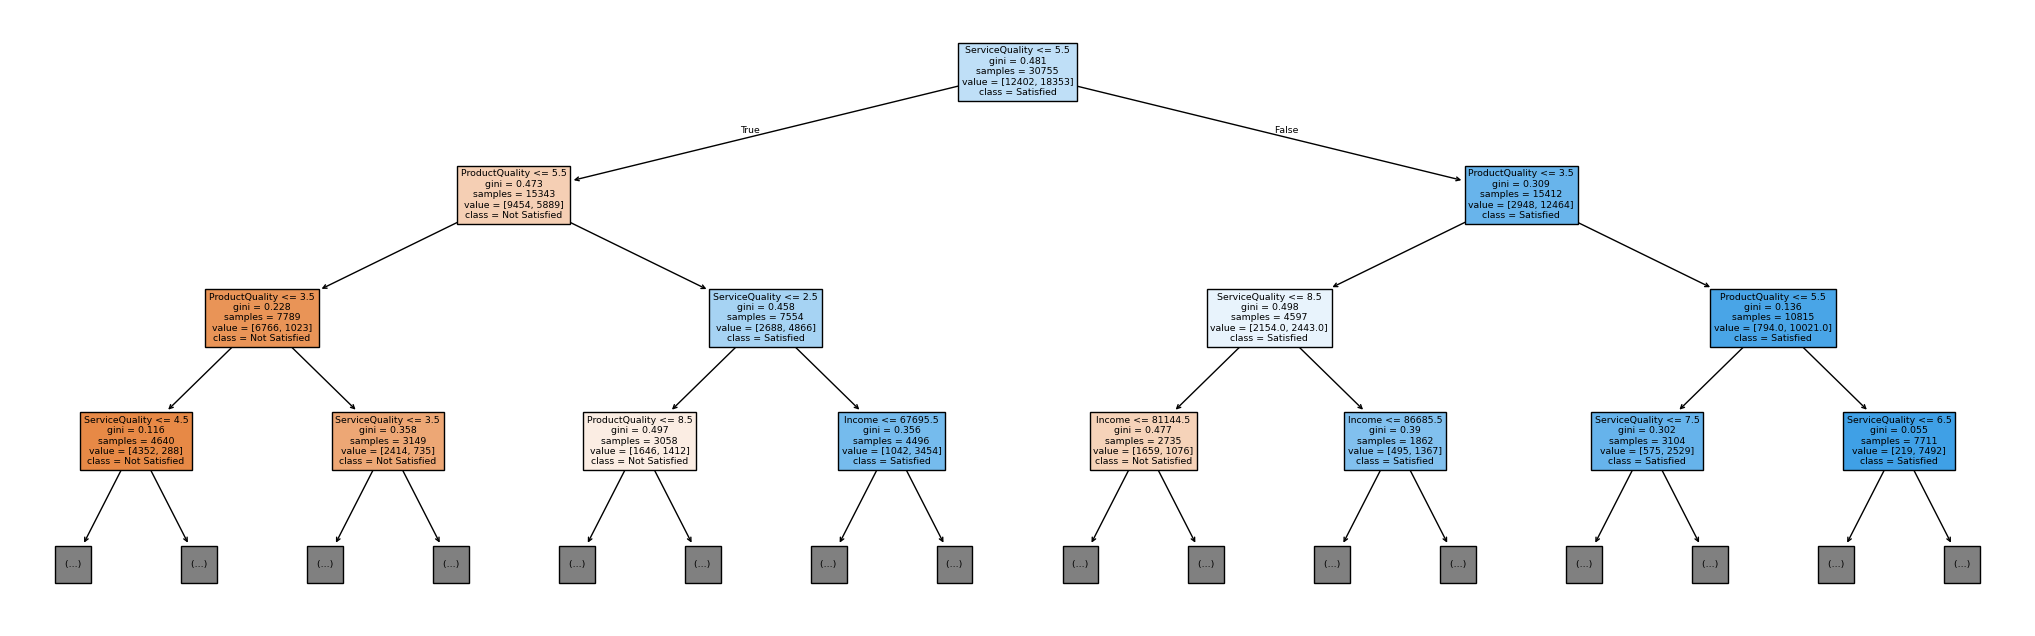

In [36]:
tree = DecisionTreeClassifier(random_state=42)

path = tree.cost_complexity_pruning_path(X_train, y_train)
effective_alphas = path.ccp_alphas
impurities = path.impurities

count_leaves = lambda tree: sum(tree.tree_.children_left[i] == tree.tree_.children_right[i] == -1 for i in range(tree.tree_.node_count))

leaf_counts = [
    DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    .fit(X_train, y_train)
    .tree_.n_leaves
    for alpha in effective_alphas[::20]
]

pruning_results = pd.DataFrame({
    'alpha': effective_alphas[::20],
    'impurity': impurities[::20],
    'leaves': leaf_counts,
    'cost function': [f"{imp:.3f} + {leaves}α" for imp, leaves in zip(impurities[::20], leaf_counts)]
})

print(pruning_results)

dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=0.000130)

dt_pruned.fit(X_train, y_train)

plt.figure(figsize=(26,8))
plot_tree(dt_pruned, filled=True, feature_names=X_train.columns, class_names=['Not Satisfied', 'Satisfied'], max_depth=3)
plt.show()

In [37]:
from sklearn.model_selection import cross_val_score

scores = []
for alpha in effective_alphas[::20]:  # sample every 20th to keep it fast
    dt = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    cv_score = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy').mean()
    scores.append((alpha, cv_score))

best_alpha, best_score = max(scores, key=lambda x: x[1])
print(f"Best alpha: {best_alpha}, CV Accuracy: {best_score:.4f}")

Best alpha: 0.0001452996024953522, CV Accuracy: 0.8555


# The Results

### Interpreting the First Three Splits

The unpruned decision tree reveals the features the model prioritizes most when predicting customer satisfaction:

- **Split 1 (Root): ServiceQuality <= 4.5** — The model considers service quality the single most important factor. Customers are first divided into those with low service ratings (left) vs. higher service ratings (right).
- **Split 2: ProductQuality <= 5.5 / ProductQuality <= 2.5** — On both branches, the model next evaluates product quality, confirming it as the second most decisive feature. Thresholds differ by branch since the populations have different distributions.
- **Split 3: Income, ProductQuality, and ServiceQuality** — The third level refines predictions further using income and additional product/service quality thresholds. Notably, income appears as a factor for the first time here, suggesting it plays a secondary role compared to quality metrics.

The tree shows that **ServiceQuality** and **ProductQuality** are the primary drivers of customer satisfaction, while demographic factors like Age, Gender, and Country play a lesser role in the initial splits.

### Pruning

Cost-complexity pruning was applied using `ccp_alpha=0.000145`, selected via 5-fold cross-validation achieving a CV accuracy of ~85.55%. The pruning path reveals the trade-off between tree complexity (number of leaves) and impurity. The chosen alpha reduces the tree from 4227 leaves (unpruned) to a much simpler structure while preserving the key decision boundaries. This prevents overfitting — the unpruned tree memorizes the training data, while the pruned tree generalizes better to unseen data.

# Random Forest

In [38]:

def find_ensemble_accuracy(n,p):
    
    ensemble_accuracy = 0
    for k in range((n + 1) // 2, n + 1):
        ensemble_accuracy += comb(n, k) * (p**k) * ((1-p)**(n-k))
    return ensemble_accuracy

print(f"ensemble accuracy = {find_ensemble_accuracy(100, 0.8)}")

rf = RandomForestClassifier(random_state=42)

parameters = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [5, 20, 50]
}
clf = GridSearchCV(rf, parameters, scoring='neg_log_loss', cv=5)

clf.fit(X_train, y_train)

print(f"Best parameters: {clf.best_params_}")
print(f"Best log loss: {clf.best_score_}")

rf_best = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5, random_state=42)
rf_best.fit(X_train, y_train)


print(f"Random Forest log loss = {log_loss(y_test, rf_best.predict_proba(X_test)[:, 1])}")
print(f"Random Forest accuracy = {rf_best.score(X_test, y_test)}")
print(f"Decision Tree log loss = {log_loss(y_test, dt_pruned.predict_proba(X_test)[:, 1])}")
print(f"Decision Tree accuracy = {dt_pruned.score(X_test, y_test)}")

ensemble accuracy = 0.9999999999948198
Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best log loss: -0.29690538815219236
Random Forest log loss = 0.3082461328759305
Random Forest accuracy = 0.8611002731174405
Decision Tree log loss = 0.3748021704732695
Decision Tree accuracy = 0.8469241773962805


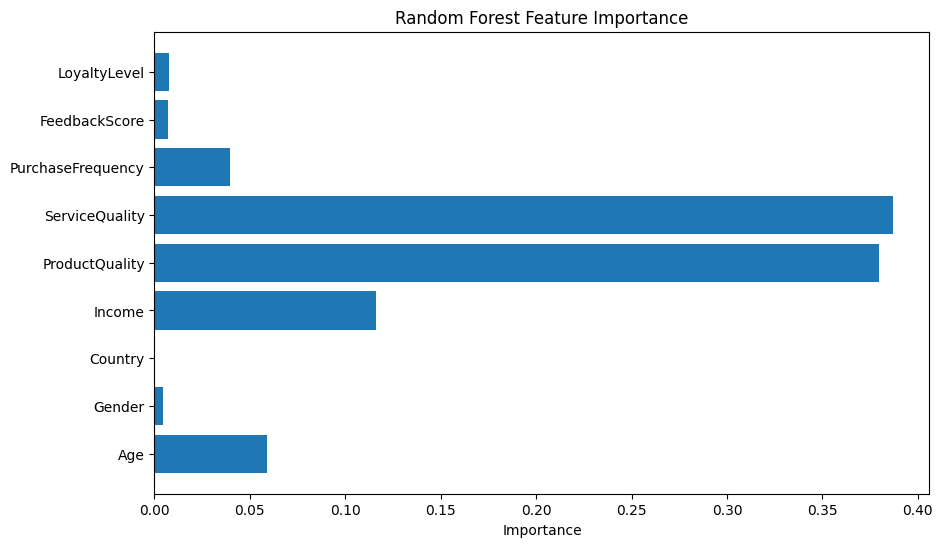

In [39]:
importances = rf_best.feature_importances_
feature_names = X_train.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.show()

# XGBoost

XGBoost is attempted here to see if sequential boosting improves on the Random Forest's $86.11\%$ accuracy. Unlike bagging, each tree corrects the residuals of the previous one. Key hyperparameters used:

| Parameter | Value |
|---|---|
| `eta` (learning rate) | 0.1 |
| `max_depth` | 3 |
| `objective` | `binary:logistic` |

XGBoost Accuracy: 0.8640


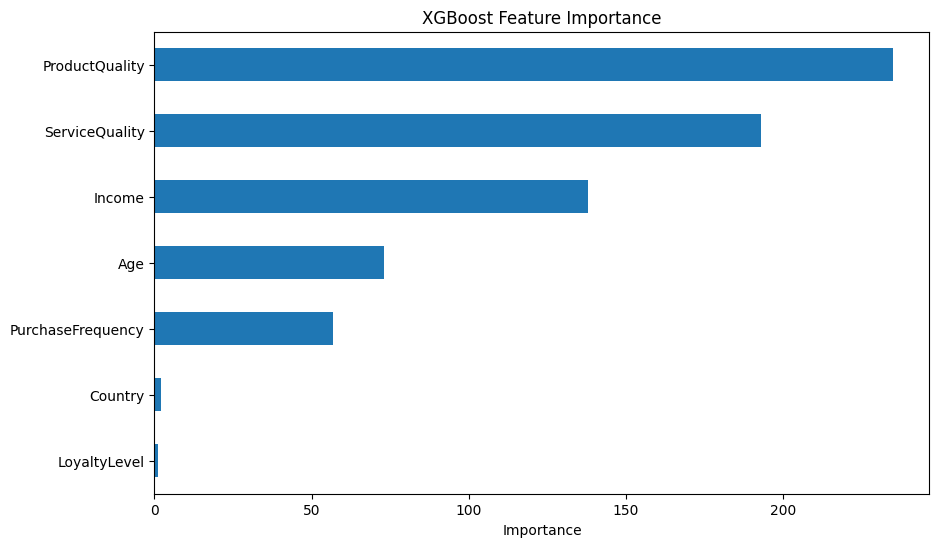

In [40]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    eta=0.1,
    max_depth=3,
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")

importance = xgb_model.get_booster().get_score(importance_type='weight')
importance_series = pd.Series(importance)
importance_series.sort_values(ascending=True, inplace=True)

plt.figure(figsize=(10, 6))
importance_series.plot(kind='barh')
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.show()

# XGBoost Results

The model uses the same encoded `X_train` / `X_test` splits as the Decision Tree and Random Forest for a direct comparison. XGBoost's feature importance (`weight`) reflects split frequency rather than impurity reduction — **ServiceQuality** and **ProductQuality** dominate, consistent with both earlier models.

| Model | Accuracy | Log Loss | AUC |
|---|---|---|---|
| Decision Tree (Pruned) | 84.69% | 0.3748 | 0.9230 |
| Random Forest (Tuned) | 86.11% | 0.3082 | 0.9414 |
| XGBoost | 86.40% | 0.2958 | 0.9444 |

XGBoost outperforms both prior models on every metric. The most meaningful gain is in log loss — dropping from $0.3082$ to $0.2958$ — indicating that sequential boosting produces better-calibrated probability estimates than bagging.

                   Decision Tree  Random Forest  XGBoost
Country                   0.0000         0.0000   0.0029
Gender                    0.0000         0.0044   0.0000
FeedbackScore             0.0000         0.0072   0.0000
LoyaltyLevel              0.0000         0.0074   0.0014
PurchaseFrequency         0.0237         0.0395   0.0815
Age                       0.0480         0.0588   0.1044
Income                    0.1099         0.1163   0.1974
ProductQuality            0.4051         0.3797   0.3362
ServiceQuality            0.4133         0.3867   0.2761


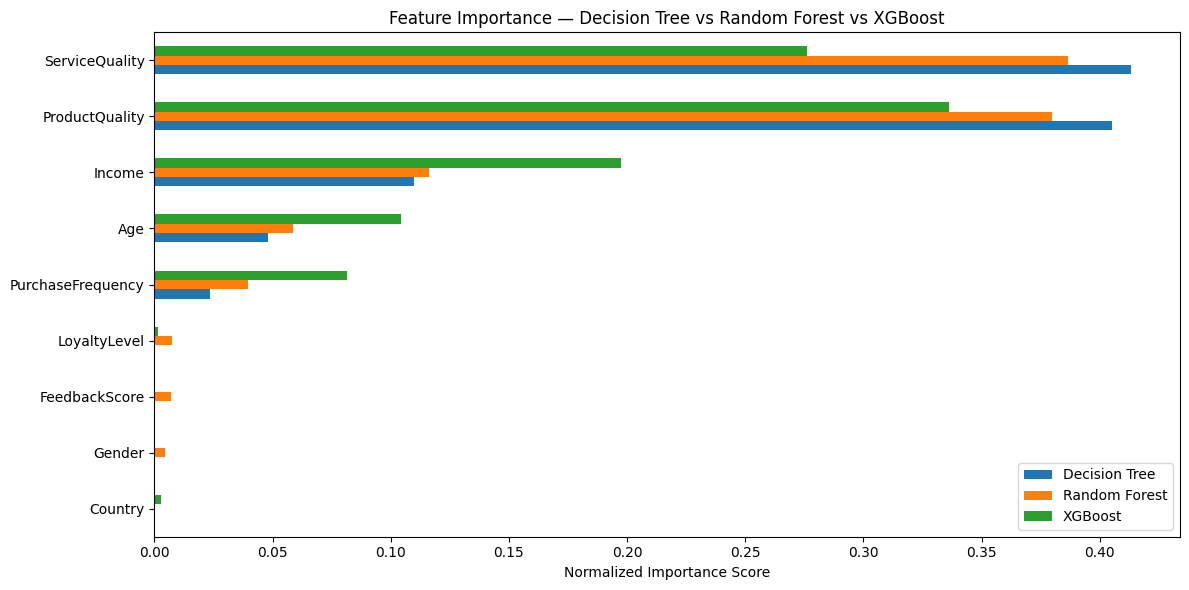

In [41]:
# Normalize XGBoost weight importance to sum=1 so all three are on the same scale
xgb_imp_raw = xgb_model.get_booster().get_score(importance_type='weight')
xgb_imp = pd.Series(xgb_imp_raw).reindex(X_train.columns).fillna(0)
xgb_imp = xgb_imp / xgb_imp.sum()

importance_df = pd.DataFrame({
    'Decision Tree': dt_pruned.feature_importances_,
    'Random Forest': rf_best.feature_importances_,
    'XGBoost':       xgb_imp.values,
}, index=X_train.columns).sort_values('Random Forest', ascending=True)

print(importance_df.round(4).to_string())

importance_df.plot(kind='barh', figsize=(12, 6))
plt.xlabel('Normalized Importance Score')
plt.title('Feature Importance — Decision Tree vs Random Forest vs XGBoost')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Feature Importance Comparison

Feature rankings are remarkably consistent across all three models despite using different importance methods — MDI for the Decision Tree and Random Forest, split frequency (normalized) for XGBoost:

| Rank | Decision Tree | Random Forest | XGBoost |
|---|---|---|---|
| 1 | ServiceQuality | ServiceQuality | ServiceQuality |
| 2 | ProductQuality | ProductQuality | ProductQuality |
| 3 | Income | Income | Income |
| 4 | PurchaseFrequency | PurchaseFrequency | PurchaseFrequency |
| 5 | FeedbackScore | LoyaltyLevel | FeedbackScore |
| 6 | LoyaltyLevel | FeedbackScore | LoyaltyLevel |
| 7 | Age | Age | Age |
| 8 | Gender | Gender | Gender |
| 9 | Country | Country | Country |

The top 4 features are identical across all three models. **ServiceQuality** and **ProductQuality** are the clear dominant predictors regardless of algorithm — their importance is not an artifact of any single model's assumptions. Demographic features (Age, Gender, Country) consistently rank at the bottom, reinforcing that satisfaction is driven by experience quality, not customer profile.

# Random Forest Results

## Model Performance

Hyperparameter tuning was conducted using `GridSearchCV` with 5-fold cross-validation over the following search space:

| Hyperparameter | Values Tested |
|---|---|
| `n_estimators` | 50, 100 |
| `max_depth` | 3, 5, 7, 10 |
| `min_samples_split` | 5, 20, 50 |

The optimal configuration was found to be `n_estimators=100`, `max_depth=10`, and `min_samples_split=5`, yielding a test accuracy of $86.11\%$ and a log loss of $0.3082$.

The ensemble accuracy calculation uses the binomial probability that a majority of $n = 100$ independent classifiers, each with individual accuracy $p = 0.80$, will vote correctly:

$$P(\text{majority correct}) = \sum_{k=\lceil n/2 \rceil}^{n} \binom{n}{k} p^k (1-p)^{n-k} \approx 99.99\%$$

This demonstrates the theoretical power of majority voting in ensemble methods — even individually weak learners become highly accurate when combined.

## Decision Tree vs. Random Forest

| Metric | Decision Tree (Pruned) | Random Forest (Tuned) |
|---|---|---|
| Accuracy | 84.69% | 86.11% |
| Log Loss | 0.3748 | 0.3082 |

The Random Forest outperforms the pruned decision tree by approximately $1.4\%$ in accuracy and achieves a notably lower log loss ($0.3082$ vs. $0.3748$), indicating that the Random Forest's predicted probabilities are better calibrated. This is expected — the Random Forest reduces variance by averaging predictions across 100 decorrelated trees, each trained on bootstrapped samples with random feature subsets. The single decision tree, even with optimal pruning, remains susceptible to the specific patterns in its training data. The lower log loss is particularly significant because it reflects not just whether the model gets the right answer, but how confident it is in that answer.

## Variable Importance

The feature importance plot from the Random Forest reveals a clear hierarchy among predictors. **ServiceQuality** emerges as the most important feature, consistent with the decision tree's root split — it contributes more to reducing impurity across all 100 trees than any other variable. **ProductQuality** ranks second, reinforcing the pattern observed in the decision tree's second-level splits. **Income** serves as a moderate contributor, first appearing at the third level of the decision tree, suggesting it plays a secondary but meaningful role in distinguishing satisfied from unsatisfied customers.

The remaining features — **PurchaseFrequency**, **FeedbackScore**, and **LoyaltyLevel** — contribute moderately, while **Age**, **Gender**, and **Country** rank lowest. The minimal importance of demographic variables suggests that customer satisfaction is driven primarily by the quality of the experience rather than by who the customer is.

## Business Implications

The convergence of both the decision tree and random forest models on the same key features provides strong evidence for strategic action. **ServiceQuality** is the single strongest predictor of customer satisfaction — investing in customer service training, reducing response times, and enhancing the overall service experience should be the company's highest priority. **ProductQuality** as the second most important factor means that maintaining consistent product standards directly impacts satisfaction outcomes.

**Income** as a tertiary factor suggests that higher-income customers may hold different expectations — targeted strategies for different income brackets could improve satisfaction across segments. Importantly, the negligible importance of **Age**, **Gender**, and **Country** indicates that marketing and retention strategies should focus on service and product improvements rather than demographic targeting, as satisfaction appears to be driven by experience quality universally across customer groups.

# Confusion Matrix and ROC Curve

In [42]:
from sklearn.metrics import confusion_matrix, log_loss
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt_pred  = dt_pruned.predict(X_test)
rf_pred  = rf_best.predict(X_test)

cm_dt  = confusion_matrix(y_test, dt_pred)
cm_rf  = confusion_matrix(y_test, rf_pred)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"Confusion Matrix — Decision Tree:\n{cm_dt}")
print(f"\nConfusion Matrix — Random Forest:\n{cm_rf}")
print(f"\nConfusion Matrix — XGBoost:\n{cm_xgb}")

dt_probs_cm  = dt_pruned.predict_proba(X_test)[:, 1]
rf_probs_cm  = rf_best.predict_proba(X_test)[:, 1]

for name, pred, probs in [
    ("Decision Tree", dt_pred,    dt_probs_cm),
    ("Random Forest", rf_pred,    rf_probs_cm),
    ("XGBoost",       y_pred_xgb, y_pred_proba_xgb),
]:
    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy_score(y_test, pred):.4f}")
    print(f"  Precision: {precision_score(y_test, pred):.4f}")
    print(f"  Recall:    {recall_score(y_test, pred):.4f}")
    print(f"  F1 Score:  {f1_score(y_test, pred):.4f}")
    print(f"  Log Loss:  {log_loss(y_test, probs):.4f}")

Confusion Matrix — Decision Tree:
[[2440  646]
 [ 531 4072]]

Confusion Matrix — Random Forest:
[[2484  602]
 [ 466 4137]]

Confusion Matrix — XGBoost:
[[2501  585]
 [ 461 4142]]

Decision Tree:
  Accuracy:  0.8469
  Precision: 0.8631
  Recall:    0.8846
  F1 Score:  0.8737
  Log Loss:  0.3748

Random Forest:
  Accuracy:  0.8611
  Precision: 0.8730
  Recall:    0.8988
  F1 Score:  0.8857
  Log Loss:  0.3082

XGBoost:
  Accuracy:  0.8640
  Precision: 0.8762
  Recall:    0.8998
  F1 Score:  0.8879
  Log Loss:  0.2958


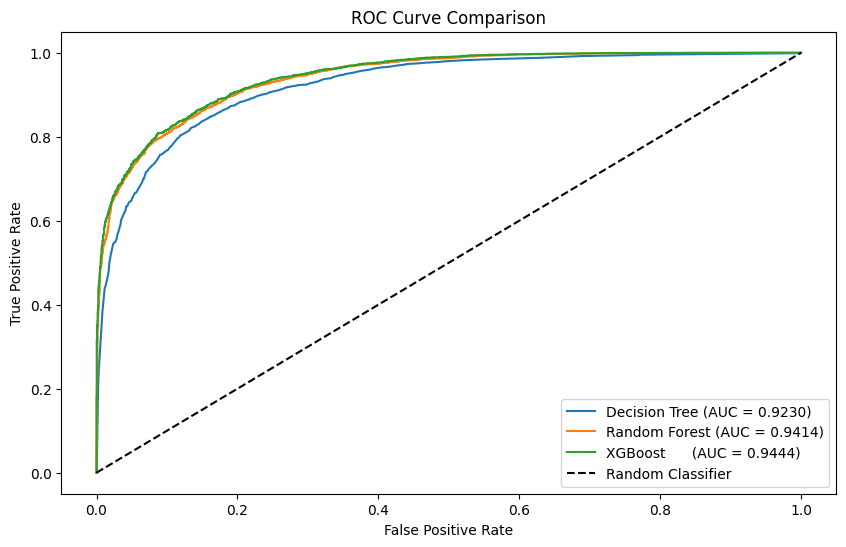

Decision Tree AUC: 0.9230
Random Forest AUC: 0.9414
XGBoost AUC:       0.9444


In [43]:
from sklearn.metrics import roc_curve, roc_auc_score

dt_probs  = dt_pruned.predict_proba(X_test)[:, 1]
rf_probs  = rf_best.predict_proba(X_test)[:, 1]

dt_fpr,  dt_tpr,  _ = roc_curve(y_test, dt_probs)
rf_fpr,  rf_tpr,  _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, y_pred_proba_xgb)

dt_auc  = roc_auc_score(y_test, dt_probs)
rf_auc  = roc_auc_score(y_test, rf_probs)
xgb_auc = roc_auc_score(y_test, y_pred_proba_xgb)

plt.figure(figsize=(10, 6))
plt.plot(dt_fpr,  dt_tpr,  label=f'Decision Tree (AUC = {dt_auc:.4f})')
plt.plot(rf_fpr,  rf_tpr,  label=f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost      (AUC = {xgb_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

print(f"Decision Tree AUC: {dt_auc:.4f}")
print(f"Random Forest AUC: {rf_auc:.4f}")
print(f"XGBoost AUC:       {xgb_auc:.4f}")

# Part 3: Model Evaluation and Interpretation

## Confusion Matrix and Classification Metrics

| Metric | Decision Tree (Pruned) | Random Forest (Tuned) | XGBoost |
|---|---|---|---|
| True Negatives | 2,440 | 2,484 | 2,501 |
| False Positives | 646 | 602 | 585 |
| False Negatives | 531 | 466 | 461 |
| True Positives | 4,072 | 4,137 | 4,142 |
| Accuracy | 84.69% | 86.11% | 86.40% |
| Precision | 86.31% | 87.30% | 87.62% |
| Recall | 88.46% | 89.88% | 89.98% |
| F1 Score | 87.37% | 88.57% | 88.79% |
| Log Loss | 0.3748 | 0.3082 | 0.2958 |

All three models improve sequentially across every metric. XGBoost edges out the Random Forest on accuracy ($86.40\%$ vs $86.11\%$), recall ($89.98\%$ vs $89.88\%$), and most notably log loss ($0.2958$ vs $0.3082$) — meaning XGBoost's predicted probabilities are the best calibrated of the three. The consistent reduction in False Negatives across models (531 → 466 → 461) is particularly meaningful here, as each false negative represents a genuinely satisfied customer being misclassified as unsatisfied.

## ROC Curve and AUC

| Model | AUC |
|---|---|
| Decision Tree (Pruned) | 0.9230 |
| Random Forest (Tuned) | 0.9414 |
| XGBoost | 0.9444 |

XGBoost achieves the highest AUC at $0.9444$, narrowly ahead of the Random Forest ($0.9414$) and well above the Decision Tree ($0.9230$). The gap between Random Forest and XGBoost is small, but XGBoost's ROC curve sits consistently above the Random Forest's across all thresholds, confirming its edge is not threshold-dependent.

## Final Model Selection

**XGBoost is the strongest model** across all evaluation metrics — accuracy, precision, recall, F1, log loss, and AUC. While the margin over the Random Forest is narrow (roughly $0.3\%$ in accuracy, $0.012$ in log loss), XGBoost's sequential boosting approach squeezes out additional performance by directly correcting the residual errors the Random Forest leaves behind. The lower log loss in particular indicates XGBoost assigns probabilities with greater confidence and accuracy, which matters for any downstream decision system using predicted probabilities rather than hard classifications.

**ServiceQuality** and **ProductQuality** remain the dominant predictors across all three models — confirmed by the decision tree's split structure, the Random Forest's MDI importance, and XGBoost's split frequency importance. Retention strategy should concentrate on service and product experience improvements, as demographic variables (Age, Gender, Country) contribute minimally to predictive power in all three models.